# Correlation decoding

In this jupyter notebook we will test if the decoder performance is better when there is more neuron

In [1]:
# Import libraries

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

# All regions


In [2]:
def linear_reg_coef(df):


    # Extract the values of interest from the dataframe
    # Peak decoding accuracy - array
    decoder_acc = np.array(df['Decoding max (%)'])

    # Number of units in the session - array
    nb_units = np.array(df['Nombre neurones'])

    # Apply linear regression between the two variables of interest

    from sklearn.linear_model import LinearRegression

    # Linear regression
    reg = LinearRegression()

    # Transform X and Y to have the shape required by sklearn 
    # https://stackoverflow.com/questions/51150153/valueerror-expected-2d-array-got-1d-array-instead

    X = nb_units.reshape(-1, 1)
    Y = decoder_acc.reshape(-1,1)

    reg.fit(X,Y)

    a = reg.coef_
    b = reg.intercept_

    res = stats.linregress(nb_units,decoder_acc)

    return a,b, res

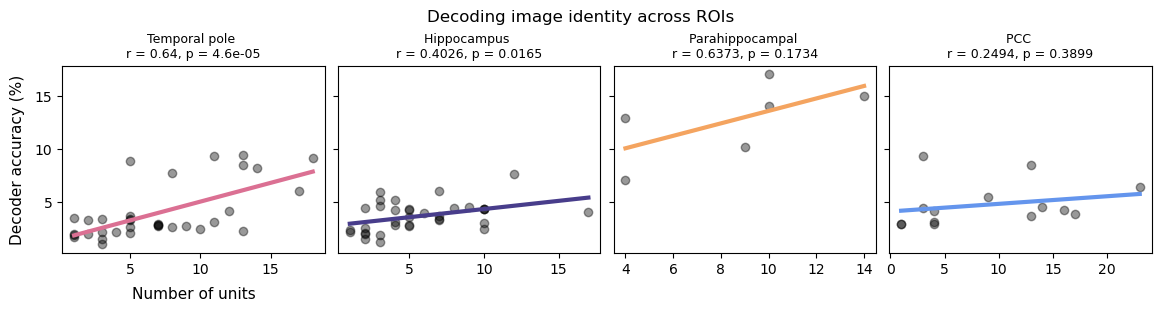

In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Path where decoding performance are stored
path_csv = 'path2data/data/Decoding/'

# Load dataframes for each ROI
df_tp = pd.read_csv(path_csv+'Decoding_TP.csv')
df_hippocampus = pd.read_csv(path_csv+'Decoding_Hippocampus.csv')
df_parahippocampal = pd.read_csv(path_csv+'Decoding_Parahippocampal.csv')
df_pcc = pd.read_csv(path_csv+'Decoding_PCC.csv')


# Extract coefficients in linear regression
tp_a, tp_b, res_tp = linear_reg_coef(df_tp)
hippocampus_a, hippocampus_b, res_hippocampus = linear_reg_coef(df_hippocampus)
parahippocampal_a, parahippocampal_b, res_parahippocampal = linear_reg_coef(df_parahippocampal)
pcc_a, pcc_b, res_pcc = linear_reg_coef(df_pcc)


# Plot part
# Plot the scatter and the line of the linear regression

fig, (ax1,ax2,ax3,ax4) = plt.subplots(1,4,figsize=(11.5,3),layout='constrained',sharey=True)

########### Temporal pole ###########
ax1.scatter(np.array(df_tp['Nombre neurones']),np.array(df_tp['Decoding max (%)']),color='k',alpha=0.4)
ax1.set_xlabel('Number of units', fontsize=11,labelpad=7)
ax1.set_ylabel('Decoder accuracy (%)', fontsize=11, labelpad=7)
# Draw linear regression line
ordonne_tp = np.linspace(np.min(np.array(df_tp['Nombre neurones'])),np.max(np.array(df_tp['Nombre neurones'])),np.max(np.array(df_tp['Nombre neurones']))-np.min(np.array(df_tp['Nombre neurones'])))
ax1.plot(ordonne_tp,np.squeeze(tp_a*ordonne_tp+tp_b),color='palevioletred',linewidth=3)
ax1.set_title('Temporal pole \nr = '+str(round(res_tp.rvalue,4))+', p = ' + str(round(res_tp.pvalue,6)),fontsize=9)

########### Hippocampus ###########
ax2.scatter(np.array(df_hippocampus['Nombre neurones']),np.array(df_hippocampus['Decoding max (%)']),color='k',alpha=0.4)
# Draw linear regression line
ordonne_hipp = np.linspace(np.min(np.array(df_hippocampus['Nombre neurones'])),np.max(np.array(df_hippocampus['Nombre neurones'])),
                           np.max(np.array(df_hippocampus['Nombre neurones']))-np.min(np.array(df_hippocampus['Nombre neurones'])))
ax2.plot(ordonne_hipp,np.squeeze(hippocampus_a*ordonne_hipp+hippocampus_b),color='darkslateblue',linewidth=3)
ax2.set_title('Hippocampus \nr = '+str(round(res_hippocampus.rvalue,4))+', p = ' + str(round(res_hippocampus.pvalue,4)),fontsize=9)


########### Parahippocampal ###########
ax3.scatter(np.array(df_parahippocampal['Nombre neurones']),np.array(df_parahippocampal['Decoding max (%)']),color='k',alpha=0.4)
# Draw linear regression line
ordonne_parahipp = np.linspace(np.min(np.array(df_parahippocampal['Nombre neurones'])),np.max(np.array(df_parahippocampal['Nombre neurones'])),
                           np.max(np.array(df_parahippocampal['Nombre neurones']))-np.min(np.array(df_parahippocampal['Nombre neurones'])))
ax3.plot(ordonne_parahipp,np.squeeze(parahippocampal_a*ordonne_parahipp+parahippocampal_b),color='sandybrown',linewidth=3)
ax3.set_title('Parahippocampal \nr = '+str(round(res_parahippocampal.rvalue,4))+', p = ' + str(round(res_parahippocampal.pvalue,4)),fontsize=9)




########### PCC ###########
ax4.scatter(np.array(df_pcc['Nombre neurones']),np.array(df_pcc['Decoding max (%)']),color='k',alpha=0.4)
# Draw linear regression line
ordonne_pcc = np.linspace(np.min(np.array(df_pcc['Nombre neurones'])),np.max(np.array(df_pcc['Nombre neurones'])),
                           np.max(np.array(df_pcc['Nombre neurones']))-np.min(np.array(df_pcc['Nombre neurones'])))
ax4.plot(ordonne_pcc,np.squeeze(pcc_a*ordonne_pcc+pcc_b),color='cornflowerblue',linewidth=3)
ax4.set_title('PCC \nr = '+str(round(res_pcc.rvalue,4))+', p = ' + str(round(res_pcc.pvalue,4)),fontsize=9)

fig.suptitle('Decoding image identity across ROIs',fontsize=12)
plt.savefig('C:/Users/dornier/PhD/Article/Concept_Cells_temporal_pole/Figures/Figure4/Decoding/Decoding_All_ROIs_v2.svg')